First 5 records:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September

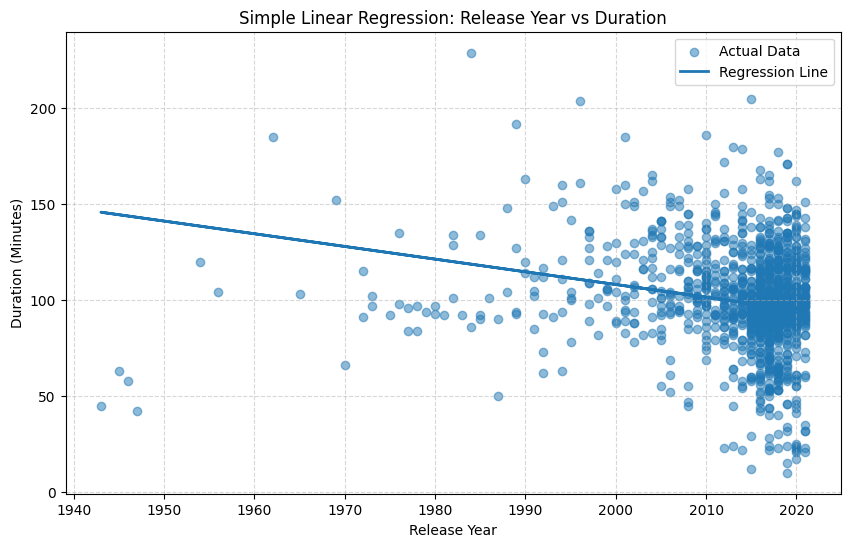

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# Load LOCAL dataset (uploaded in Colab)
# -----------------------------
df = pd.read_csv("netflix_titles.csv")   # <-- change name if different

print("First 5 records:")
print(df.head())

# -----------------------------
# Data Cleaning
# -----------------------------

# Keep only Movies
df = df[df['type'] == 'Movie']

# FIX: use raw string r'(\d+)' to avoid warning
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Drop missing values
df = df[['release_year', 'duration_minutes']].dropna()

# -----------------------------
# Define Features and Target
# -----------------------------
X = df[['release_year']]
y = df['duration_minutes']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)

print(f"\nModel Accuracy (R^2 Score): {r2:.4f}")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, linewidth=2, label='Regression Line')

plt.title('Simple Linear Regression: Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
